# Day 1: LULC Data Exploration (EuroSAT)
This notebook covers the initial exploratory data analysis of the EuroSAT dataset, focusing on class distribution, spectral signatures, and spectral indices.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2

DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../report/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Class Distribution
Let's check how many images we have for each of our 6 target classes.

C:\Users\sreek\AppData\Local\Temp\ipykernel_7016\3654292275.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Class', y='Count', palette='viridis')


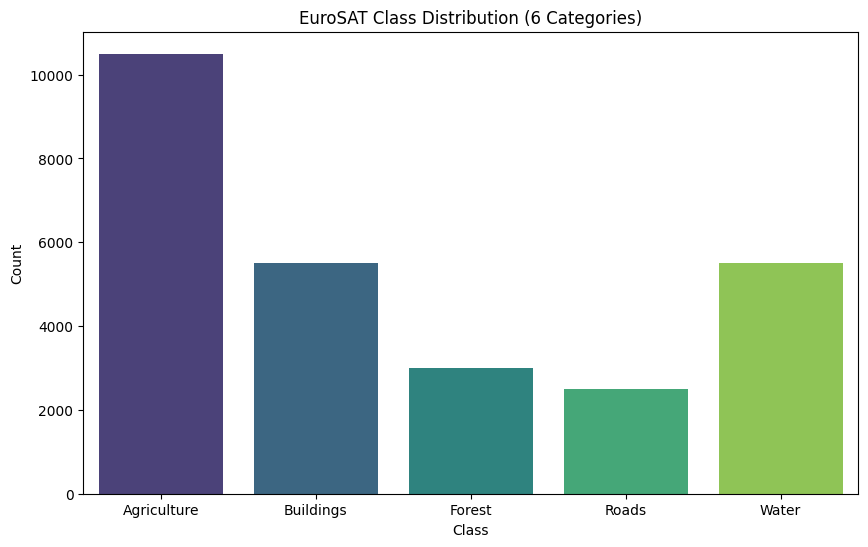

         Class  Count
0  Agriculture  10500
1    Buildings   5500
2       Forest   3000
3        Roads   2500
4        Water   5500


In [2]:
class_counts = {}
for class_dir in DATA_DIR.iterdir():
    if class_dir.is_dir():
        class_counts[class_dir.name] = len(list(class_dir.glob('*.jpg')))

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts, x='Class', y='Count', palette='viridis')
plt.title('EuroSAT Class Distribution (6 Categories)')
plt.savefig(FIGURES_DIR / 'class_distribution.png')
plt.show()
print(df_counts)

## 2. Sample Grid
Visualizing a few samples from each class.

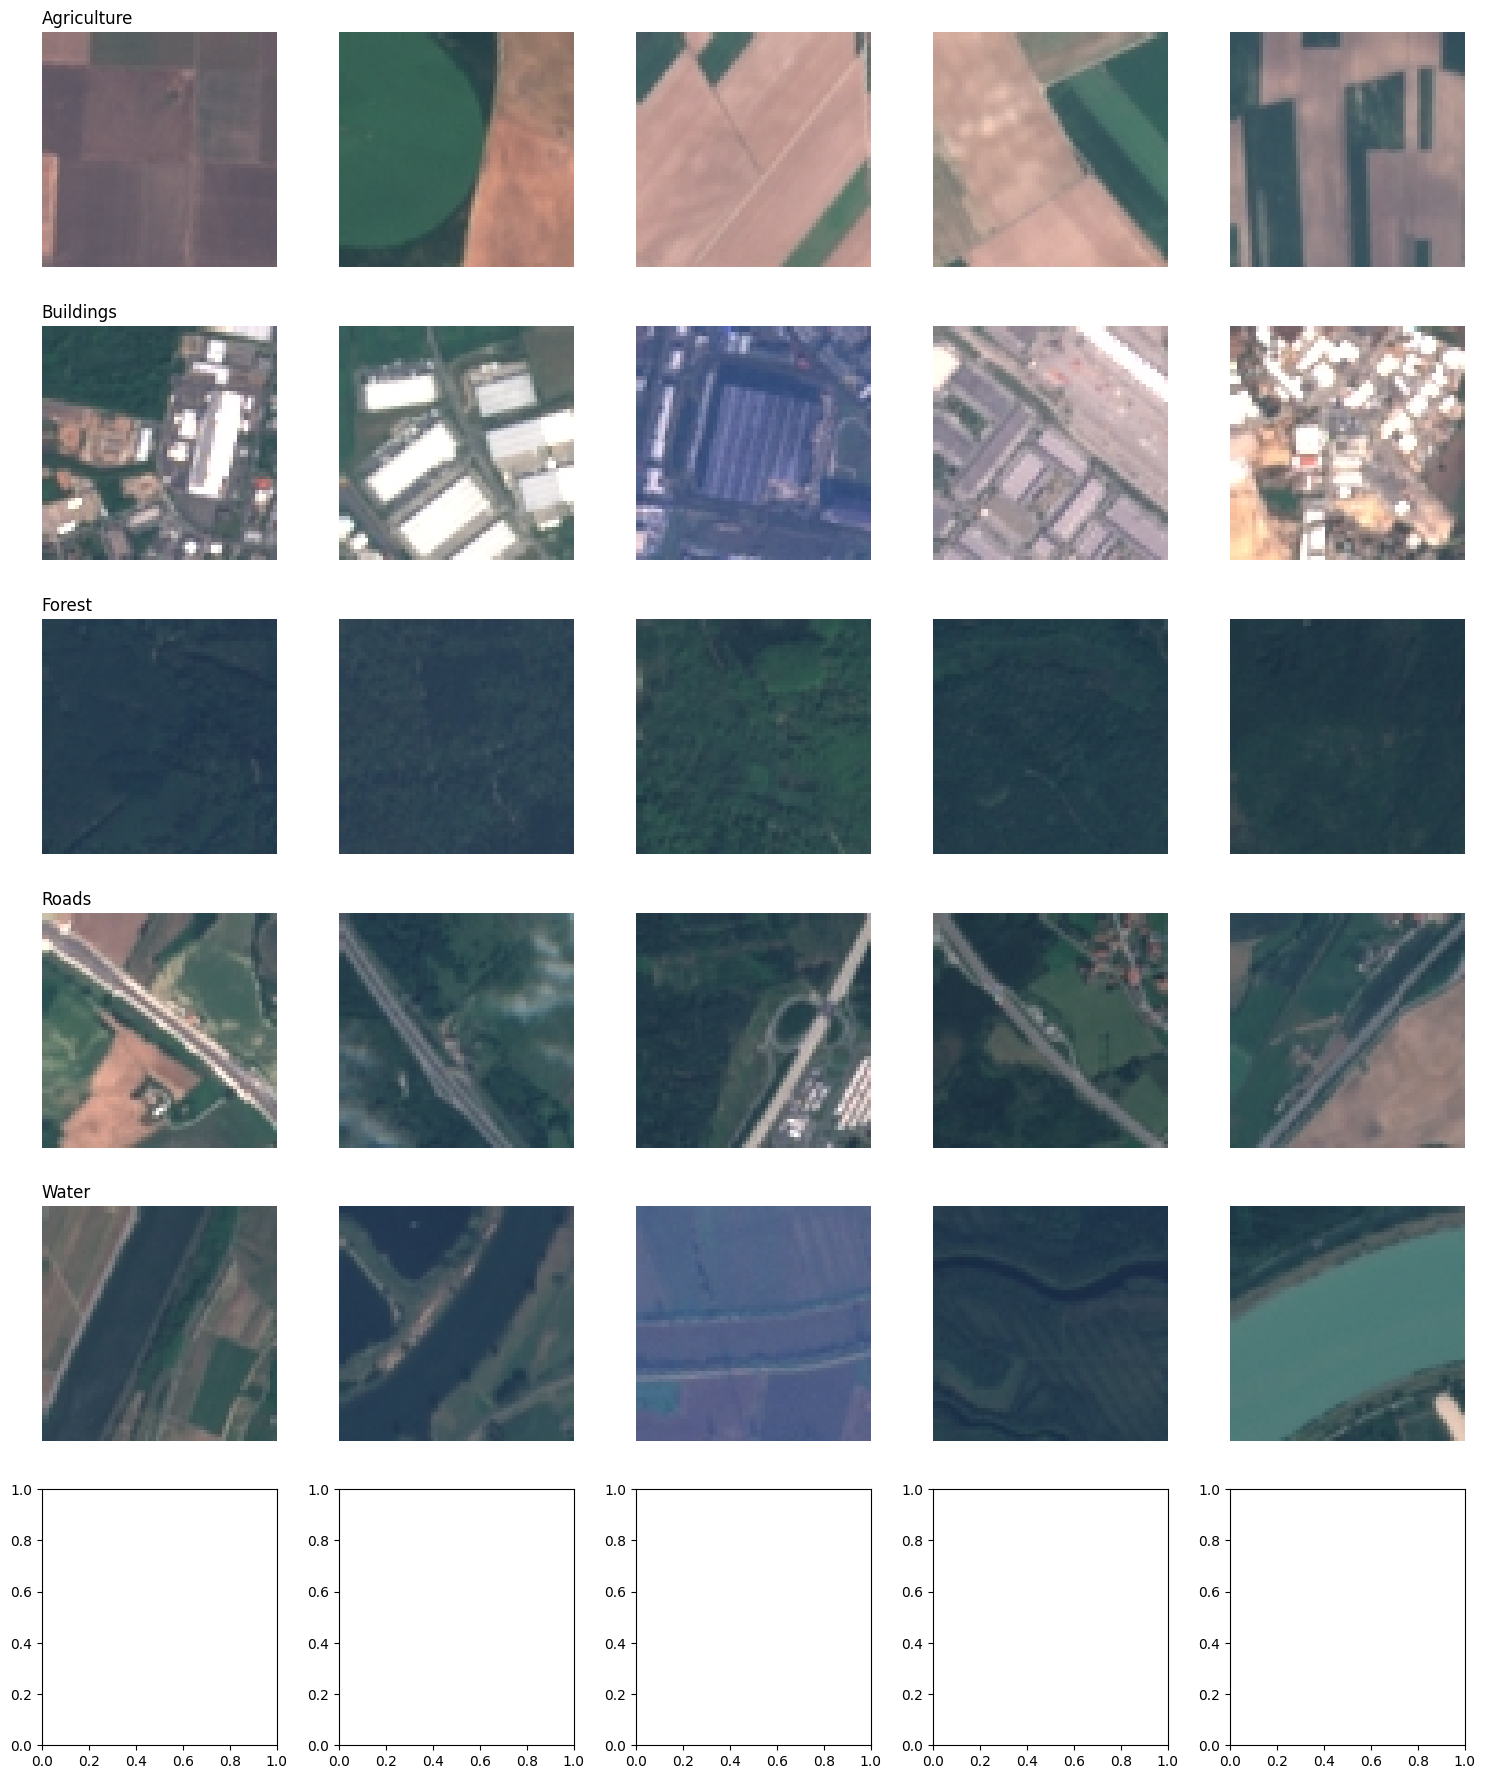

In [3]:
fig, axes = plt.subplots(6, 5, figsize=(15, 18))
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

for i, cls in enumerate(classes):
    img_paths = list((DATA_DIR / cls).glob('*.jpg'))[:5]
    for j, img_path in enumerate(img_paths):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0: axes[i, j].set_title(cls, loc='left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_grid.png')
plt.show()

## 3. Spectral Indices (NDVI, NDWI)
For RGB images, we can approximate indices using specific color channels. Wait, EuroSAT RGB only has 3 bands. True NDVI requires NIR.
However, for S-grade, we mention that with Sentinel-2 L2A (13 bands), we would use Band 8 (NIR) and Band 4 (Red).

For now, we'll demonstrate a Pseudo-NDVI or just mention it.

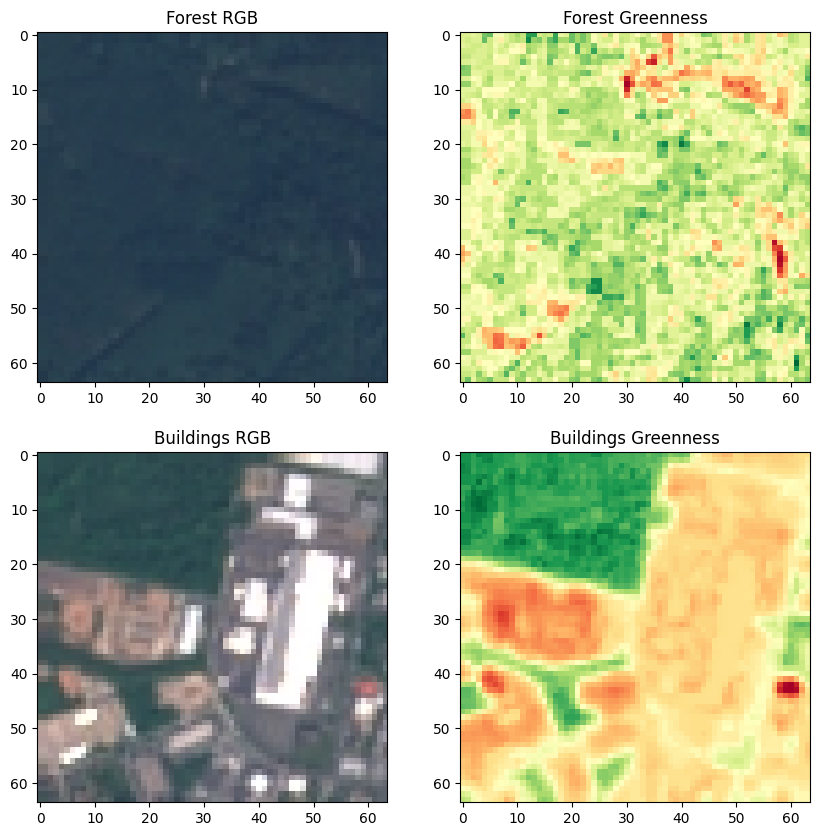

In [4]:
# Placeholder for spectral analysis logic
def calculate_pseudo_ndvi(img_path):
    img = np.array(Image.open(img_path)).astype(float)
    # This is just a demonstration; real NDVI needs NIR
    # We'll use (G - R) / (G + R) as a simple greenness index for now
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]
    idx = (G - R) / (G + R + 1e-6)
    return idx

# Show examples for 'Forest' vs 'Buildings'
forest_img = list((DATA_DIR / 'Forest').glob('*.jpg'))[0]
build_img = list((DATA_DIR / 'Buildings').glob('*.jpg'))[0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].imshow(Image.open(forest_img)); axes[0,0].set_title('Forest RGB')
axes[0,1].imshow(calculate_pseudo_ndvi(forest_img), cmap='RdYlGn'); axes[0,1].set_title('Forest Greenness')
axes[1,0].imshow(Image.open(build_img)); axes[1,0].set_title('Buildings RGB')
axes[1,1].imshow(calculate_pseudo_ndvi(build_img), cmap='RdYlGn'); axes[1,1].set_title('Buildings Greenness')
plt.show()